In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

## Read in the data and check for Null values

In [2]:
movies_df = pd.read_csv('/content/movies.csv')
ratings_df = pd.read_csv('/content/ratings.csv')
print(movies_df.isnull().sum())
print(ratings_df.isnull().sum())

movieId    0
title      0
genres     0
dtype: int64
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


## Like the modules, need to map the movieId and userId to consecutive integers

In [4]:
unique_user_ids = ratings_df['userId'].unique()
unique_movie_ids = ratings_df['movieId'].unique()
#encode the user ids and the movie ids
encoded_user_ids = {x: i for i, x in enumerate(unique_user_ids)}
encoded_movie_ids = {x: i for i, x in enumerate(unique_movie_ids)}
#encode the inverse of both
inverse_encoded_user_ids = {i: x for i, x in enumerate(unique_user_ids)}
inverse_encoded_movie_ids = {i: x for i, x in enumerate(unique_movie_ids)}
ratings_df['userId'] = ratings_df['userId'].map(encoded_user_ids)
ratings_df['movieId'] = ratings_df['movieId'].map(encoded_movie_ids)

num_users = len(encoded_user_ids)
num_movies = len(encoded_movie_ids)
unique_ratings = ratings_df['rating'].unique().tolist()
ratings_df['rating'] = ratings_df['rating'].values.astype(np.float32)

## Split data into training and test sets

In [5]:
X = ratings_df[['userId', 'movieId']].values
#Normalize targets to be between 0,1
scaler = MinMaxScaler()
y = scaler.fit_transform(ratings_df[['rating']].values.reshape(-1,1))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Build the model

In [20]:
#We are going to follow along with what the modules did
#set dimensionality of embedding space
embedding_dim = 50

#Create a subclass of the tensorflow model class
class BTS(tf.keras.Model):
  def __init__(self, num_users, num_movies, embedding_dim, **kwargs):
    super(BTS, self).__init__(**kwargs)
    self.num_users = num_users
    self.num_movies = num_movies
    self.embedding_dim = embedding_dim
    self.user_embedding = tf.keras.layers.Embedding(
        num_users,
        embedding_dim,
        embeddings_initializer = 'he_normal',
        embeddings_regularizer = tf.keras.regularizers.l2(1e-6)
    )
    self.user_bias = tf.keras.layers.Embedding(num_users,1)
    self.movie_embedding = tf.keras.layers.Embedding(
        num_movies,
        embedding_dim,
        embeddings_initializer = 'he_normal',
        embeddings_regularizer = tf.keras.regularizers.l2(1e-6)
        )
    self.movie_bias = tf.keras.layers.Embedding(num_movies,1)
  def call(self, inputs):
    user_vector = self.user_embedding(inputs[:,0])
    user_bias = self.user_bias(inputs[:,0])
    movie_vector = self.movie_embedding(inputs[:,1])
    movie_bias = self.movie_bias(inputs[:,1])
    dot_user_movie = tf.tensordot(user_vector, movie_vector, 2)
    x = dot_user_movie + user_bias + movie_bias
    return tf.nn.sigmoid(x)

In [21]:
model = BTS(num_users, num_movies, embedding_dim)

In [30]:
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=[tf.keras.metrics.MeanAbsoluteError()]
)

early_stopping = EarlyStopping(monitor='val_loss',
                               patience=5,
                               min_delta=0.001,
                               mode='min')

In [31]:
%%time
#fit the model
history = model.fit(
    X_train,
    y_train,
    batch_size=128,
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping]
)

Epoch 1/50
14077/14077 [==============================] - 108s 8ms/step - loss: 0.7499 - mean_absolute_error: 0.2269 - val_loss: 0.7652 - val_mean_absolute_error: 0.2303
Epoch 2/50
14077/14077 [==============================] - 107s 8ms/step - loss: 0.8348 - mean_absolute_error: 0.2495 - val_loss: 0.8385 - val_mean_absolute_error: 0.2488
Epoch 3/50
14077/14077 [==============================] - 106s 8ms/step - loss: 0.9074 - mean_absolute_error: 0.2640 - val_loss: 0.9011 - val_mean_absolute_error: 0.2606
Epoch 4/50
14077/14077 [==============================] - 106s 8ms/step - loss: 0.9884 - mean_absolute_error: 0.2785 - val_loss: 0.9746 - val_mean_absolute_error: 0.2721
Epoch 5/50
14077/14077 [==============================] - 107s 8ms/step - loss: 1.0534 - mean_absolute_error: 0.2868 - val_loss: 1.0179 - val_mean_absolute_error: 0.2743
Epoch 6/50
14077/14077 [==============================] - 106s 8ms/step - loss: 1.1186 - mean_absolute_error: 0.2939 - val_loss: 1.0774 - val_mean_abs

In [34]:
model.summary()

Model: "bts_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_8 (Embedding)     multiple                  751150    
                                                                 
 embedding_9 (Embedding)     multiple                  15023     
                                                                 
 embedding_10 (Embedding)    multiple                  1441650   
                                                                 
 embedding_11 (Embedding)    multiple                  28833     
                                                                 
Total params: 2236656 (8.53 MB)
Trainable params: 2236656 (8.53 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


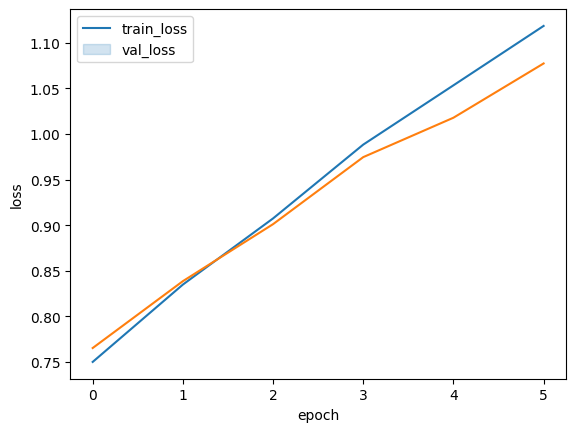

In [32]:
train_history = pd.DataFrame(history.history)
train_history['epoch'] = history.epoch
# Plot train loss
sns.lineplot(x='epoch', y ='loss', data =train_history)
# Plot validation loss
sns.lineplot(x='epoch', y ='val_loss', data =train_history)
# Add legends
plt.legend(labels=['train_loss', 'val_loss'])

## Recommend movies for a random user in the dataset

In [35]:
# Randomly select a user from the rating dataset
user_id = ratings_df.userId.sample(1).iloc[0]
# Subset the movies watched and not watched by this user
movies_watched_by_user = ratings_df[ratings_df.userId == user_id]
movies_not_watched = movies_df[
    ~movies_df["movieId"].isin(movies_watched_by_user.movieId.values)
]["movieId"]

# Find the movies not watched that contains in the rating dataset
movies_not_watched = list(
    set(movies_not_watched).intersection(set(encoded_movie_ids.keys()))
)
# Map  the movies to the indices
movies_not_watched = [[encoded_movie_ids.get(x)] for x in movies_not_watched]
# Mpa the user Id to the index
user_encoder = encoded_user_ids.get(user_id)

# Generate a dataset with two columns
# The first column is the user_encoder that is the same for all rows
# The 2nd column is the movies not watched by this user.
user_movie_array = np.hstack(
    ([[user_encoder]] * len(movies_not_watched), movies_not_watched)
)
# Forecast the ratings(probablity of this user will watch it )
ratings = model.predict(user_movie_array).flatten()
# Find the indices of the top 10 ratings by using argsort
top_ratings_indices = ratings.argsort()[-10:][::-1]
# Find the recommened movie Ids
recommended_movie_ids = [
    inverse_encoded_movie_ids.get(movies_not_watched[x][0]) for x in top_ratings_indices
]

# print("Showing recommendations for user: {}".format(user_id))
print(f"Showing recommendations for user: {user_id}")
print("====" * 20)
print("Top 10 Movies with high ratings from user")
print("----" * 20)
top_movies_user = (
    movies_watched_by_user.sort_values(by="rating", ascending=False)
    .head(10)
    .movieId.values
)
movie_df_rows = movies_df[movies_df["movieId"].isin(top_movies_user)]
for row in movie_df_rows.itertuples():
    print(f"The title: {row.title}; The genres: {row.genres}")

print("----" * 20)
print("Top 10 movie recommendations")
print("----" * 20)
recommended_movies = movies_df[movies_df["movieId"].isin(recommended_movie_ids)]
for row in recommended_movies.itertuples():
    print(f"The title: {row.title}; The genres: {row.genres}")

291/291 [==============================] - 0s 1ms/step
Showing recommendations for user: 9205
Top 10 Movies with high ratings from user
--------------------------------------------------------------------------------
The title: Kicking and Screaming (1995); The genres: Comedy|Drama
The title: Vampire in Brooklyn (1995); The genres: Comedy|Horror|Romance
The title: Jupiter's Wife (1994); The genres: Documentary
The title: Angela (1995); The genres: Drama
The title: Addiction, The (1995); The genres: Drama|Horror
The title: Star Wars: Episode IV - A New Hope (1977); The genres: Action|Adventure|Sci-Fi
The title: House Arrest (1996); The genres: Children|Comedy
The title: Infinity (1996); The genres: Drama
The title: Alley Cats, The (1966); The genres: Drama
The title: Say It Isn't So (2001); The genres: Comedy|Romance
--------------------------------------------------------------------------------
Top 10 movie recommendations
--------------------------------------------------------------